# Importing all Python libraries required

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier

# Loading the comp1804_coursework_dataset_23-24

In [4]:
data = pd.read_csv("comp1804_coursework_dataset_23-24.csv")

### Head of the dataset

In [5]:
data.head(10)

,par_id,paragraph,has_entity,lexicon_count,difficult_words,last_editor_gender,category,text_clarity
0,428209002237,Ramsay was born in Glasgow on 2 October 1852. ...,ORG_YES_PRODUCT_NO_PERSON_YES_,49,12.0,man,biographies,clear_enough
1,564218010072,It has been widely estimated for at least the ...,ORG_YES_PRODUCT_NO_PERSON_NO_,166,47.0,man,artificial intelligence,not_clear_enough
2,291401001672,He went on to win the Royal Medal of the Royal...,ORG_YES_PRODUCT_NO_PERSON_NO_,69,18.0,non-binary,biographies,clear_enough
3,31548004883,The changes have altered many underlying assum...,ORG_NO_PRODUCT_YES_PERSON_NO_,76,27.0,non-binary,programming,clear_enough
4,50634005146,"After these novels were published, Disraeli de...",ORG_YES_PRODUCT_YES_PERSON_YES_,200,47.0,man,biographies,not_clear_enough
5,220520007895,Philo also proposes that the order in nature m...,ORG_NO_PRODUCT_NO_PERSON_NO_,137,36.0,man,philosophy,not_clear_enough
6,6360003753,"This led to the AI spring of the early 2020s,...",ORG_YES_PRODUCT_NO_PERSON_NO_,116,47.0,man,artificial intelligence,clear_enough
7,848119011941,A second form of functionalism is based on the...,ORG_YES_PRODUCT_NO_PERSON_YES_,42,14.0,man,philosophy,not_clear_enough
8,49279000639,"The opposite of ""moral"" is ""immoral"", meaning ...",ORG_NO_PRODUCT_NO_PERSON_NO_,51,8.0,man,philosophy,clear_enough
9,79225005859,Pepys' diary provides a first-hand account of ...,ORG_NO_PRODUCT_YES_PERSON_YES_,139,31.0,man,biographies,NaN


### Tail of the dataset

In [6]:
data.tail(10)

,par_id,paragraph,has_entity,lexicon_count,difficult_words,last_editor_gender,category,text_clarity
9337,85003284,"According to this view, existence is more fun...",ORG_NO_PRODUCT_NO_PERSON_YES_,193,41.0,woman,philosophy,NaN
9338,895492012137,Virtue theory emphasises Aristotle's belief in...,ORG_YES_PRODUCT_NO_PERSON_YES_,141,35.0,man,philosophy,NaN
9339,17262004505,The following table provides a summary of sele...,ORG_YES_PRODUCT_NO_PERSON_NO_,19,8.0,man,programming,NaN
9340,31548004880,"Instead of Console.WriteLine, one could use Ms...",ORG_YES_PRODUCT_YES_PERSON_NO_,20,5.0,man,programming,NaN
9341,438219002265,Bishop is best known for his Nobel-winning wor...,ORG_YES_PRODUCT_NO_PERSON_NO_,24,10.0,man,biographies,NaN
9342,200523007578,Sir Joseph Dalton Hooker was a British botani...,ORG_YES_PRODUCT_NO_PERSON_YES_,54,16.0,man,biographies,NaN
9343,50634005203,As successful invasions of India generally cam...,ORG_YES_PRODUCT_NO_PERSON_YES_,217,46.0,woman,biographies,NaN
9344,6437003939,Hawking was born on 8 January 1942 in Oxford t...,ORG_YES_PRODUCT_NO_PERSON_YES_,91,27.0,woman,biographies,NaN
9345,725259002815,More complex tasks can be making custom data e...,ORG_YES_PRODUCT_NO_PERSON_NO_,47,15.0,man,programming,NaN
9346,109126000894,"Governments, and especially the police and cou...",ORG_NO_PRODUCT_NO_PERSON_NO_,87,8.0,man,philosophy,NaN


# Exploratory Data Analysis (EDA)

## Data Exploration

### Shape of the dataset

In [7]:
data.shape

(9347, 8)

### Columns of the dataset

In [8]:
data.columns

Index(['par_id', 'paragraph', 'has_entity', 'lexicon_count', 'difficult_words',
       'last_editor_gender', 'category', 'text_clarity'],
      dtype='object')

### Data types

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9347 entries, 0 to 9346
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   par_id              9347 non-null   int64  
 1   paragraph           9347 non-null   object 
 2   has_entity          9347 non-null   object 
 3   lexicon_count       9347 non-null   int64  
 4   difficult_words     9329 non-null   float64
 5   last_editor_gender  9347 non-null   object 
 6   category            9286 non-null   object 
 7   text_clarity        9 non-null      object 
dtypes: float64(1), int64(2), object(5)
memory usage: 584.3+ KB


### Checking null values in the dataset

In [10]:
data.isnull().sum()

par_id                   0
paragraph                0
has_entity               0
lexicon_count            0
difficult_words         18
last_editor_gender       0
category                61
text_clarity          9338
dtype: int64

In [11]:
import warnings
warnings.filterwarnings("ignore")

### Data visualisations of Category features before cleaning

####Distribution by count

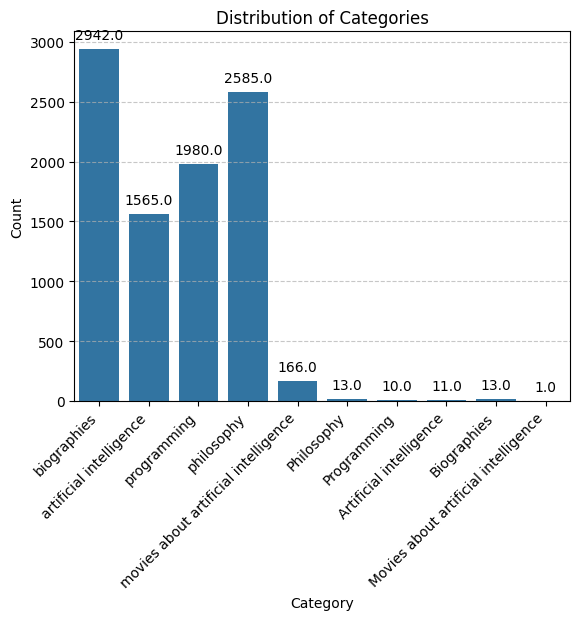

In [12]:
# Get the categories by count
categories = data['category'].value_counts().index.tolist()
data_categories = data[data['category'].isin(categories)]

# Create the vertical count plot
ax = sns.countplot(x='category', data=data_categories)

# Set the title
plt.title('Distribution of Categories')

# Add labels to the axes
plt.xlabel('Category')
plt.ylabel('Count')

# Add a grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Add count values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

# Show the plot
plt.show()

# Data cleaning and data preprocessing

## Data cleaning

In [5]:
# Dropping unnecessary columns
data = data.drop(['par_id'], axis=1)

In [6]:
# Handling missing values in 'difficult_words' and 'category' columns in the dataset
data['difficult_words'].fillna(0, inplace=True)
data = data.dropna(subset=['category'])

In [7]:
# Missing values in the dataset after data cleaning
data.isnull().sum()

paragraph                0
has_entity               0
lexicon_count            0
difficult_words          0
last_editor_gender       0
category                 0
text_clarity          9277
dtype: int64

In [8]:
# Converting the 'category' column to lowercase
data['category'] = data['category'].str.lower()

In [9]:
# Checking the unique values in the 'category' column
print(data['category'].unique())

['biographies' 'artificial intelligence' 'programming' 'philosophy'
 'movies about artificial intelligence']


### Data visualisations of Category features after cleaning

#### Distribution by count

<ipython-input-10-c6732fa9da4b>:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


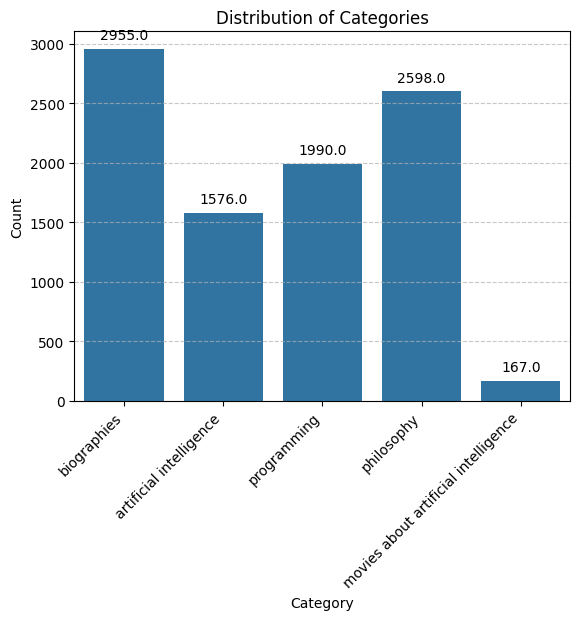

In [10]:
# Get the categories by count
categories = data['category'].value_counts().index.tolist()

# Filter the data to include only the top 5 categories
data_categories = data[data['category'].isin(categories)]

# Create the vertical count plot
ax = sns.countplot(x='category', data=data_categories)

# Set the title
plt.title('Distribution of Categories')

# Add labels to the axes
plt.xlabel('Category')
plt.ylabel('Count')

# Add a grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Add count values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

# Show the plot
plt.show()

# Data Splitting

In [11]:
# Data Splitting
X = data[['paragraph', 'has_entity']]
y = data['category']

### Splitting the data into train/test sets (80/20 split)

In [12]:
# Perform train-validation-test split
train_data, test_data = train_test_split(data, test_size=0.20, random_state=42)

In [13]:
# Text preprocessing steps
train_paragraphs = train_data['paragraph'].apply(lambda x: x.lower())  # Convert to lowercase
test_paragraphs = test_data['paragraph'].apply(lambda x: x.lower())

In [14]:
# Feature selection
train_features = train_data[['paragraph','has_entity']]
test_features = test_data[['paragraph','has_entity']]

In [15]:
# Encoding labels
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_data['category'])
test_labels = label_encoder.transform(test_data['category'])

# Data encoding

### Vectorize the text data (paragraphs)

### TF-IDF Vectorization

In [16]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)  # Limiting to top 5000 features
train_tfidf = tfidf_vectorizer.fit_transform(train_paragraphs)
test_tfidf = tfidf_vectorizer.transform(test_paragraphs)

In [17]:
# Standardize TF-IDF features for model development
scaler = StandardScaler(with_mean=False)
train_tfidf_scaled = scaler.fit_transform(train_tfidf)
test_tfidf_scaled = scaler.transform(test_tfidf)

### SMOTE for over/undersampling

In [18]:
# Check the class distribution
print("Class distribution before sampling:")
print(y.value_counts())

Class distribution before sampling:
biographies                             2955
philosophy                              2598
programming                             1990
artificial intelligence                 1576
movies about artificial intelligence     167
Name: category, dtype: int64


In [19]:
# Defining the over-sampling strategy
over_sampler = SMOTE(sampling_strategy='auto', random_state=42)

In [20]:
# Defining the under-sampling strategy
under_sampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)

In [21]:
# Define the pipeline combining over-sampling and under-sampling
sampling_pipeline = Pipeline([
    ('over_sampling', over_sampler),
    ('under_sampling', under_sampler)
])

In [22]:
# Applying the sampling pipeline to the TF-IDF features
X_train_resampled, y_train_resampled = sampling_pipeline.fit_resample(train_tfidf_scaled, train_labels)

In [23]:
# Checking the class distribution after sampling
unique_classes, class_counts = np.unique(y_train_resampled, return_counts=True)
class_distribution = dict(zip(unique_classes, class_counts))
print("\nClass distribution after sampling:")
print(class_distribution)


Class distribution after sampling:
{0: 2333, 1: 2333, 2: 2333, 3: 2333, 4: 2333}


In [24]:
# Define test data
X_test = test_tfidf_scaled
y_test = test_labels
y_train = train_labels

In [25]:
X_train_final = train_tfidf_scaled
X_test_final = test_tfidf_scaled

# Task 1: Topic Classification

### Logistic regression with hyperparameter optimisation

In [36]:
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}  # Hyperparameter grid
grid_search_lr1 = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)  # Grid search cross-validation

grid_search_lr1.fit(X_train_final, y_train)  # Perform grid search

best_lr1 = grid_search_lr1.best_estimator_  # Get the best estimator

predictions_lr_hp1 = best_lr1.predict(X_test_final)  # Make predictions

In [37]:
# Evaluate the model
print("Train Accuracy :", grid_search_lr1.best_score_)
print("\nModel 1: Logistic Regression with Hyperparameter Optimization")
print("Best Parameters:", grid_search_lr1.best_params_)
print("Classification Report:")
print(classification_report(y_test, predictions_lr_hp1))
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions_lr_hp1))

Train Accuracy : 0.921244658337525

Model 1: Logistic Regression with Hyperparameter Optimization
Best Parameters: {'C': 0.01}
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       305
           1       0.94      0.94      0.94       622
           2       1.00      0.87      0.93        30
           3       0.90      0.93      0.91       500
           4       0.95      0.96      0.95       401

    accuracy                           0.93      1858
   macro avg       0.94      0.91      0.93      1858
weighted avg       0.93      0.93      0.93      1858

Confusion Matrix:
[[268   7   0  16  14]
 [  4 583   0  32   3]
 [  0   3  26   0   1]
 [ 10  21   0 466   3]
 [  8   3   0   6 384]]


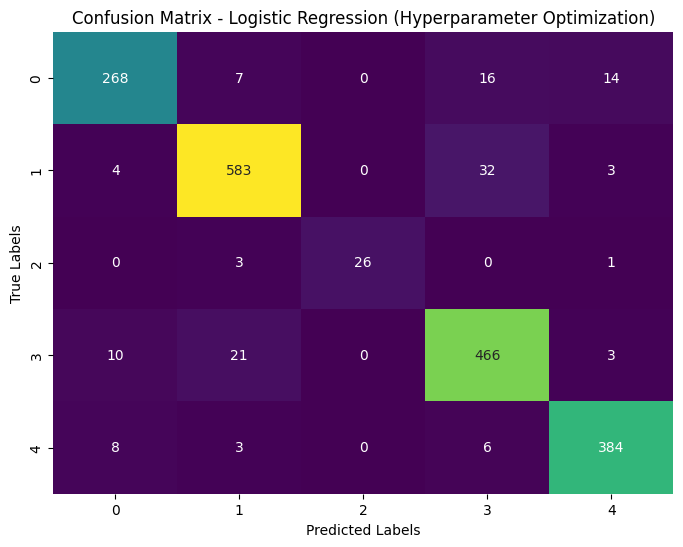

In [38]:
# Function to plot confusion matrix as heatmap
def plot_confusion_matrix(conf_matrix, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, cmap='viridis', fmt='g', cbar=False)
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()
conf_matrix_lr_hp1 = confusion_matrix(y_test, predictions_lr_hp1)
plot_confusion_matrix(conf_matrix_lr_hp1, "Confusion Matrix - Logistic Regression (Hyperparameter Optimization)")

### Random Forest classifier with hyperparameter optimisation

In [39]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf1 = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5)  # Grid search cross-validation

grid_search_rf1.fit(X_train_final, y_train)  # Perform grid search

best_rf1 = grid_search_rf1.best_estimator_  # Get the best estimator

predictions_rf_hp1 = best_rf1.predict(X_test_final)  # Make predictions

In [40]:
# Evaluate the model
print("Train Accurary :", grid_search_rf1.best_score_)
print("\nModel 2: Random Forest with Hyperparameter Optimization")
print("Best Parameters:", grid_search_rf1.best_params_)
print("Classification Report:")
print(classification_report(y_test, predictions_rf_hp1))

Train Accurary : 0.8154267665438594

Model 2: Random Forest with Hyperparameter Optimization
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.64      0.76       305
           1       0.84      0.91      0.87       622
           2       1.00      0.23      0.38        30
           3       0.77      0.88      0.82       500
           4       0.90      0.90      0.90       401

    accuracy                           0.84      1858
   macro avg       0.89      0.71      0.75      1858
weighted avg       0.85      0.84      0.84      1858



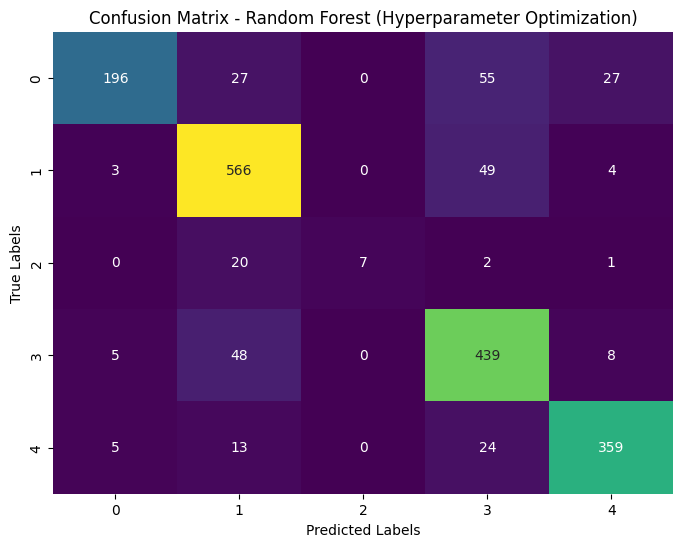

In [41]:
# Function to plot confusion matrix as heatmap
def plot_confusion_matrix(conf_matrix, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, cmap='viridis', fmt='g', cbar=False)
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()
conf_matrix_rf_hp1 = confusion_matrix(y_test, predictions_rf_hp1)
plot_confusion_matrix(conf_matrix_rf_hp1, "Confusion Matrix - Random Forest (Hyperparameter Optimization)")

# Task 2: Text Clarity

In [26]:
# Defining the labeling criteria and apply labels to all rows
for index, row in data.sample(n=9286, random_state=42).iterrows():
    if 45 <= row['lexicon_count'] <= 120 and row['difficult_words'] < 50:
        data.at[index, 'text_clarity'] = 'clear_enough'
    else:
        data.at[index, 'text_clarity'] = 'not_clear_enough'

In [27]:
# Save the labeled dataset to a new CSV file
data.to_csv("task2_dataset.csv", index=False)

In [28]:
# Converting the 'paragraph' column to lowercase
data['paragraph'] = data['paragraph'].str.lower()

In [29]:
# Text processing for 'paragraph' column using CountVectorizer
vectorizer = CountVectorizer(stop_words='english')
paragraph_features = vectorizer.fit_transform(data['paragraph'])

In [30]:
# Handle categorical variables using label encoding
label_encoder = LabelEncoder()
data['text_clarity'] = label_encoder.fit_transform(data['text_clarity'])

## Data splitting

In [31]:
# Split the dataset into train/test
X = data['paragraph']     #input feature
y = data['text_clarity']  #label

In [32]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Data preprocessing

In [33]:
# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(stop_words='english'), 'paragraph')
    ])

## Model Development

####Logistic Regression with hyperparameter optimisation

In [34]:
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}  # Hyperparameter grid
grid_search_lr_hp2 = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)  # Grid search cross-validation

grid_search_lr_hp2.fit(X_train_final, y_train)  # Perform grid search

best_lr2 = grid_search_lr_hp2.best_estimator_  # Get the best estimator

predictions_lr_hp2 = best_lr2.predict(X_test_final)  # Make predictions

In [35]:
# Evaluate the model
print("Train Accuracy :", grid_search_lr_hp2.best_score_)
print("\nModel 1: Logistic Regression with Hyperparameter Optimization")
print("Best Parameters:", grid_search_lr_hp2.best_params_)
print("Classification Report:")
print(classification_report(y_test, predictions_lr_hp2))
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions_lr_hp2))

Train Accuracy : 0.5853555745884144

Model 1: Logistic Regression with Hyperparameter Optimization
Best Parameters: {'C': 0.001}
Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.43      0.45       720
           1       0.66      0.70      0.68      1138

    accuracy                           0.59      1858
   macro avg       0.56      0.56      0.56      1858
weighted avg       0.59      0.59      0.59      1858

Confusion Matrix:
[[308 412]
 [345 793]]


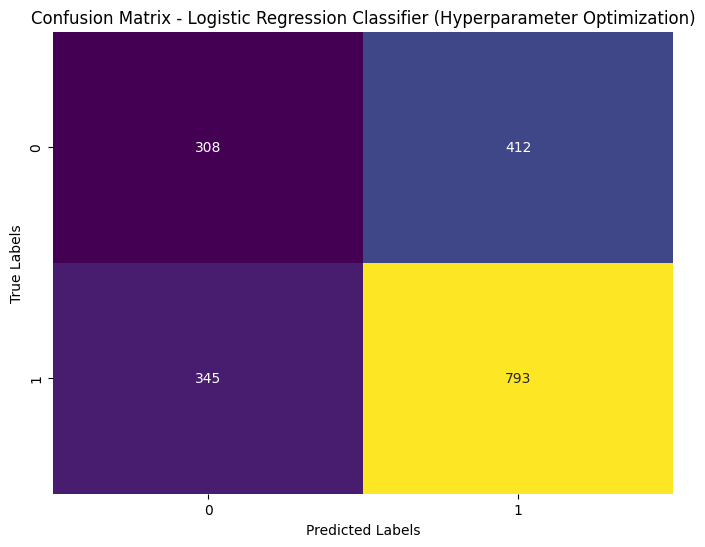

In [36]:
# Function to plot confusion matrix as heatmap
def plot_confusion_matrix(conf_matrix, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, cmap='viridis', fmt='g', cbar=False)
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()
conf_matrix_lr_hp2 = confusion_matrix(y_test, predictions_lr_hp2)
plot_confusion_matrix(conf_matrix_lr_hp2, "Confusion Matrix - Logistic Regression Classifier (Hyperparameter Optimization)")

####Random Forest Classifier with hyperparamter optimisation

In [37]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf2 = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5)  # Grid search cross-validation

grid_search_rf2.fit(X_train_final, y_train)  # Perform grid search

best_rf2 = grid_search_rf2.best_estimator_  # Get the best estimator

predictions_rf_hp2 = best_rf2.predict(X_test_final)  # Make predictions

In [38]:
# Evaluate the model
print("Train Accuracy :", grid_search_rf2.best_score_)
print("\nModel 2: Random Forest Classifier with Hyperparameter Optimization")
print("Best Parameters:", grid_search_rf2.best_params_)
print("Classification Report:")
print(classification_report(y_test, predictions_rf_hp2))
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions_rf_hp2))

Train Accuracy : 0.8416811452343081

Model 2: Random Forest Classifier with Hyperparameter Optimization
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.73      0.80       720
           1       0.85      0.93      0.89      1138

    accuracy                           0.86      1858
   macro avg       0.86      0.83      0.84      1858
weighted avg       0.86      0.86      0.85      1858

Confusion Matrix:
[[ 527  193]
 [  75 1063]]


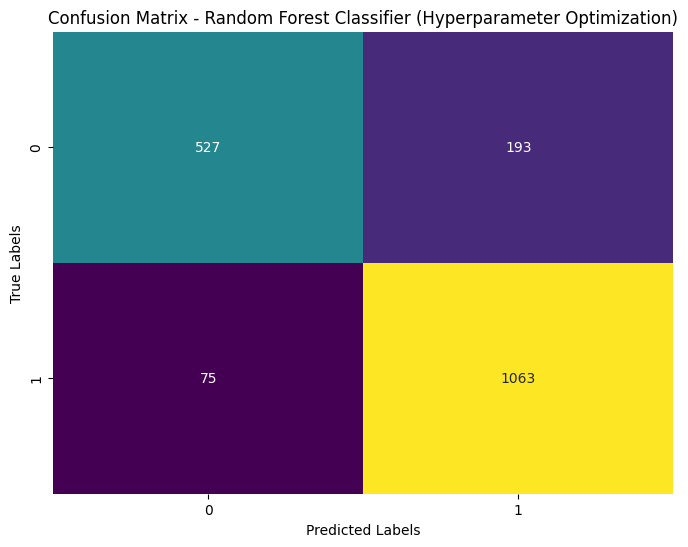

In [39]:
# Function to plot confusion matrix as heatmap
def plot_confusion_matrix(conf_matrix, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, cmap='viridis', fmt='g', cbar=False)
    plt.title(title)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()
conf_matrix_rf_hp2 = confusion_matrix(y_test, predictions_rf_hp2)
plot_confusion_matrix(conf_matrix_rf_hp2, "Confusion Matrix - Random Forest Classifier (Hyperparameter Optimization)")